<a href="https://colab.research.google.com/github/woo-jungnam/th-deep/blob/main/2001230540_NguyenThanhNam_Bai1_Tuan05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Flatten, TimeDistributed
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


In [2]:

# Example dummy data for demonstration (replace with your actual data)
image_height, image_width = 64, 64
num_channels = 1 # Grayscale. Use 3 for RGB
num_classes = 2 # Cat or Dog

# Assuming a sequence of rows for an image
# Reshape each image (height, width, channels) to (height, width * channels) for LSTM input
X_train = np.random.rand(100, image_height, image_width, num_channels) # 100 training images
y_train = np.random.randint(0, num_classes, 100) # 100 labels

X_test = np.random.rand(20, image_height, image_width, num_channels) # 20 testing images
y_test = np.random.randint(0, num_classes, 20) # 20 labels

# Reshape input for LSTM: (samples, timesteps, features)
# Here, timesteps could be image_height, and features could be image_width * num_channels
X_train_reshaped = X_train.reshape(X_train.shape[0], image_height, image_width * num_channels)
X_test_reshaped = X_test.reshape(X_test.shape[0], image_height, image_width * num_channels)

print(f"Original X_train shape: {X_train.shape}")
print(f"Reshaped X_train shape for LSTM: {X_train_reshaped.shape}")
print(f"y_train shape: {y_train.shape}")

Original X_train shape: (100, 64, 64, 1)
Reshaped X_train shape for LSTM: (100, 64, 64)
y_train shape: (100,)


### Building the LSTM Model

We will construct a simple sequential LSTM model. For image data, a common approach when using LSTMs is to feed either flattened rows/columns of the image or features extracted by a CNN layer into the LSTM. Here, we'll use the flattened rows approach.

In [3]:
# Define the LSTM model
model = Sequential([
    LSTM(128, input_shape=(image_height, image_width * num_channels), return_sequences=False), # return_sequences=False for last LSTM layer
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax') # Output layer for binary classification (Cat/Dog)
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,202 (418.76 KB)

 Trainable params: 107,202 (418.76 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

Once you have your actual data loaded and preprocessed, you can train the model.

In [7]:

history = model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, validation_split=0.2)

print("Model training complete using dummy data.")

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - accuracy: 0.4750 - loss: 0.7499 - val_accuracy: 0.4000 - val_loss: 0.7127
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5500 - loss: 0.6943 - val_accuracy: 0.4000 - val_loss: 0.7504
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5500 - loss: 0.6847 - val_accuracy: 0.3500 - val_loss: 0.7077
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5500 - loss: 0.6865 - val_accuracy: 0.4000 - val_loss: 0.7198
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6125 - loss: 0.6725 - val_accuracy: 0.6000 - val_loss: 0.6930
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7000 - loss: 0.6722 - val_accuracy: 0.4000 - val_loss: 0.7117
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5875 - loss: 0.6605 - val_accuracy: 0.4000 - val_loss: 0.7580
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5500 - loss: 0.6638 - val_accuracy: 0.4000 - val_loss: 0.7789

### Plotting Training History

After training your model, it's good practice to visualize the training and validation loss and accuracy to understand the model's performance and identify potential overfitting.

In [6]:
import matplotlib.pyplot as plt

if 'history' in locals() and history is not None:
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()
else:
    print("Training history not available. Please run the model training cell first.")

Training history not available. Please run the model training cell first.


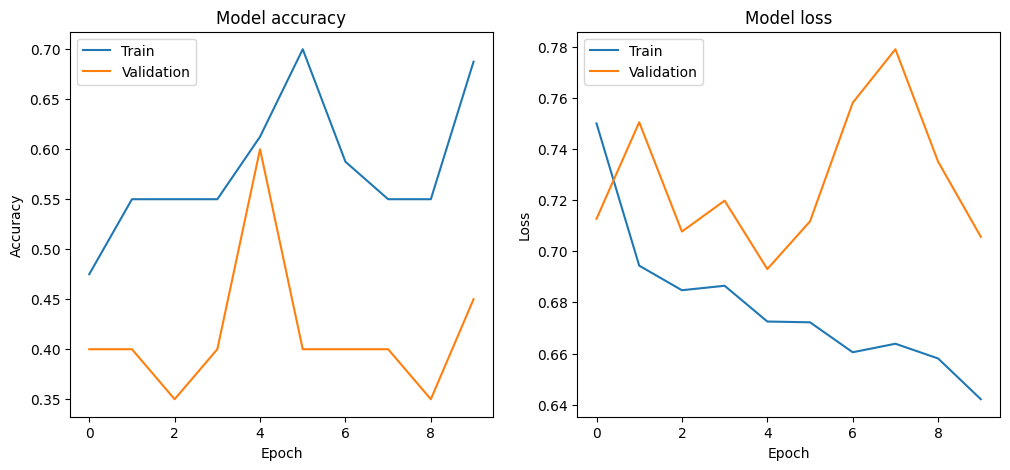

In [8]:
import matplotlib.pyplot as plt

if 'history' in locals() and history is not None:
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()
else:
    print("Training history not available. Please run the model training cell first.")

In [5]:


print("Model evaluation skipped for now. Please uncomment and run after training the model with your actual data.")

Model evaluation skipped for now. Please uncomment and run after training the model with your actual data.
